# SolarScan — 03 · Modèle de référence (baseline)

**Avant** d'entraîner un réseau de neurones, on établit une **barre à battre** avec des modèles simples et rapides (CPU suffit).

On va comparer :
1. **Dummy** (prédit toujours la classe majoritaire) → pour *prouver* que l'accuracy ment.
2. **Random Forest** sur les pixels bruts → un vrai baseline honnête.

Métrique de référence : le **macro-F1** (vu en EDA).

> ⚠️ **Prérequis : avoir exécuté le notebook 02** (il crée les fichiers `splits/train.csv`, `val.csv`, `test.csv`).

## 0. Imports

In [ ]:
%pip install -q scikit-learn pandas pillow matplotlib

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

DATA_DIR = Path('../data')
SPLITS = Path('../splits')

## 1. Charger les splits (créés au notebook 02)

In [2]:
train_df = pd.read_csv(SPLITS / 'train.csv')
test_df = pd.read_csv(SPLITS / 'test.csv')
print('train :', len(train_df), '| test :', len(test_df))
train_df.head()

train : 14000 | test : 3000


,filepath,classe
0,images/11336.jpg,No-Anomaly
1,images/12983.jpg,No-Anomaly
2,images/11259.jpg,No-Anomaly
3,images/13083.jpg,No-Anomaly
4,images/5806.jpg,Cell


## 2. Transformer les images en vecteurs

Un modèle classique (non-CNN) ne comprend pas une image : on **aplatit** chaque image 24×40 en un vecteur de **960 valeurs** (les pixels), normalisées entre 0 et 1.

> ⏳ On charge ~17 000 images : compte **1 à 2 minutes**.

In [3]:
def load_split(df):
    X = np.stack([
        np.asarray(Image.open(DATA_DIR / fp).convert('L'), dtype=np.float32).ravel()
        for fp in df['filepath']
    ]) / 255.0
    y = df['classe'].values
    return X, y

X_train, y_train = load_split(train_df)
X_test, y_test = load_split(test_df)
print('X_train :', X_train.shape, '| X_test :', X_test.shape)

X_train : (14000, 960) | X_test : (3000, 960)


## 3. Baseline 0 — Dummy (le piège de l'accuracy)

Ce modèle prédit **toujours** No-Anomaly. Regarde bien l'écart entre accuracy et macro-F1.

In [4]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred = dummy.predict(X_test)
print('Accuracy :', round(accuracy_score(y_test, pred), 3))
print('Macro-F1 :', round(f1_score(y_test, pred, average='macro'), 3))

Accuracy : 0.5
Macro-F1 : 0.056


➡️ ~50 % d'accuracy mais un macro-F1 minuscule : la preuve chiffrée qu'**en données déséquilibrées, l'accuracy est trompeuse**.

## 4. Baseline 1 — Random Forest sur les pixels

Un vrai modèle, simple et rapide. `class_weight='balanced_subsample'` compense le déséquilibre.

> ⏳ L'entraînement prend ~1 minute.

In [5]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced_subsample',
    n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print('Accuracy :', round(accuracy_score(y_test, pred), 3))
print('Macro-F1 :', round(f1_score(y_test, pred, average='macro'), 3))
print()
print(classification_report(y_test, pred))

Accuracy : 0.621
Macro-F1 : 0.328

                precision    recall  f1-score   support

          Cell       0.75      0.07      0.14       281
    Cell-Multi       0.47      0.07      0.13       193
      Cracking       0.75      0.31      0.44       141
         Diode       0.87      0.61      0.72       225
   Diode-Multi       0.80      0.15      0.26        26
      Hot-Spot       0.00      0.00      0.00        37
Hot-Spot-Multi       0.42      0.14      0.20        37
    No-Anomaly       0.60      0.99      0.74      1500
Offline-Module       0.80      0.29      0.43       124
     Shadowing       0.88      0.29      0.44       159
       Soiling       0.33      0.03      0.06        31
    Vegetation       0.57      0.30      0.39       246

      accuracy                           0.62      3000
     macro avg       0.60      0.27      0.33      3000
  weighted avg       0.64      0.62      0.55      3000



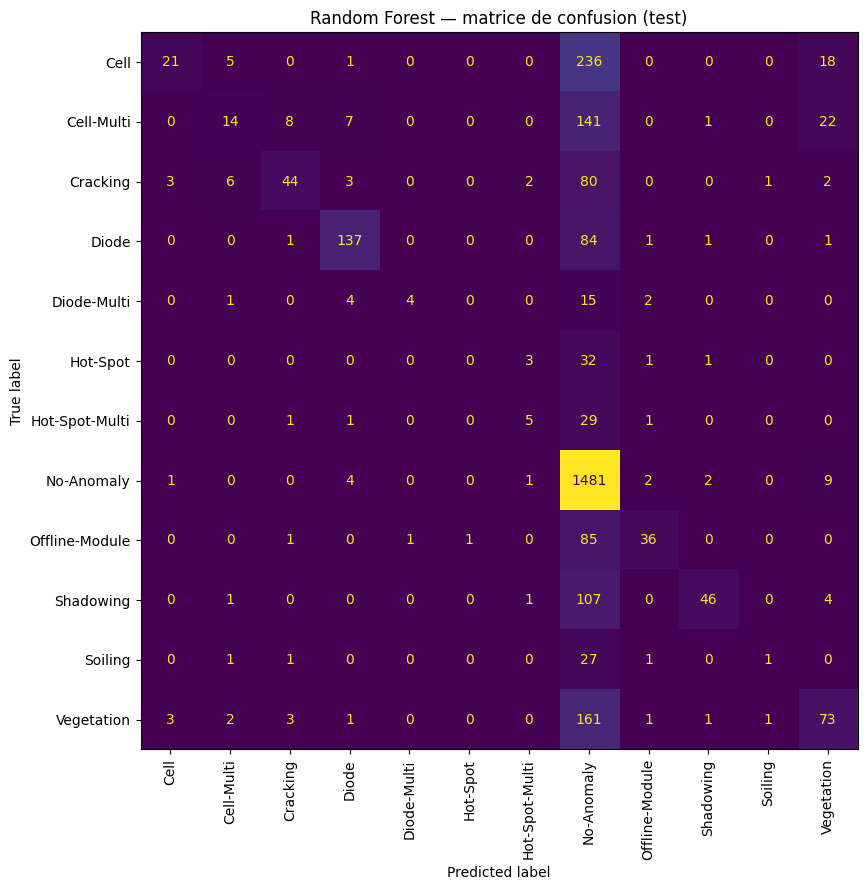

In [6]:
labels = sorted(set(y_train))
cm = confusion_matrix(y_test, pred, labels=labels)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=90, colorbar=False)
plt.title('Random Forest — matrice de confusion (test)')
plt.tight_layout()
plt.show()

## 5. Bilan

- Le **Dummy** confirme : accuracy élevée ≠ bon modèle (macro-F1 ridicule).
- Le **Random Forest** sur pixels bruts donne notre **barre de référence** (macro-F1 à noter).
- Regarde la matrice de confusion : quelles classes sont confondues ? (souvent les rares, et No-Anomaly vs anomalies discrètes).

**Note ton macro-F1 de référence ici → _____**

➡️ Prochain notebook : **CNN par transfer learning (ResNet-18)**. Objectif : **battre ce baseline** en exploitant les *motifs spatiaux* (ce qu'un Random Forest sur pixels à plat ne sait pas faire). Comme c'est lourd sur CPU, on le fera sur **Google Colab (GPU gratuit)**.